In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
report_df = pd.read_csv('WH Report_preprocessed.csv')
report_df.head()

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
0,Afghanistan,Asia,2010,29185507.0,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
1,Afghanistan,Asia,2011,30117413.0,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
2,Afghanistan,Asia,2012,31161376.0,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
3,Afghanistan,Asia,2013,32269589.0,3.572,7.725,0.484,52.56,0.578,0.061,0.823,0.621,0.273
4,Afghanistan,Asia,2014,33370794.0,3.131,7.718,0.526,52.88,0.509,0.104,0.871,0.532,0.375


In [3]:
#  Create filter
BM = report_df.year == 2019

# Use filter
report2019_df = report_df[BM]

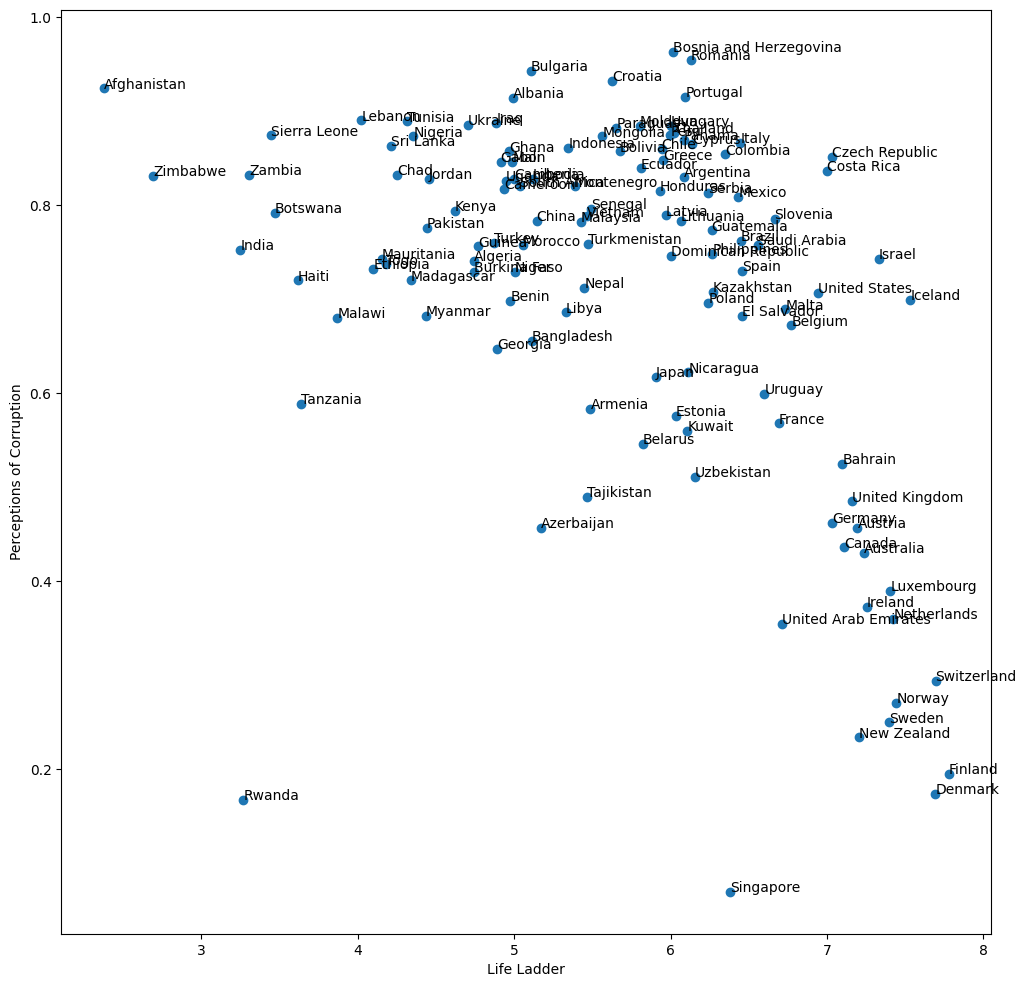

In [7]:
plt.figure(figsize=(12,12))
plt.scatter(report2019_df.Life_Ladder, report2019_df.Perceptions_of_corruption)
for _, row in report2019_df.iterrows():
    #attach name to data point
    plt.annotate(row.Name, (row.Life_Ladder, row.Perceptions_of_corruption))
plt.xlabel('Life Ladder')
plt.ylabel('Perceptions of Corruption')
plt.show()

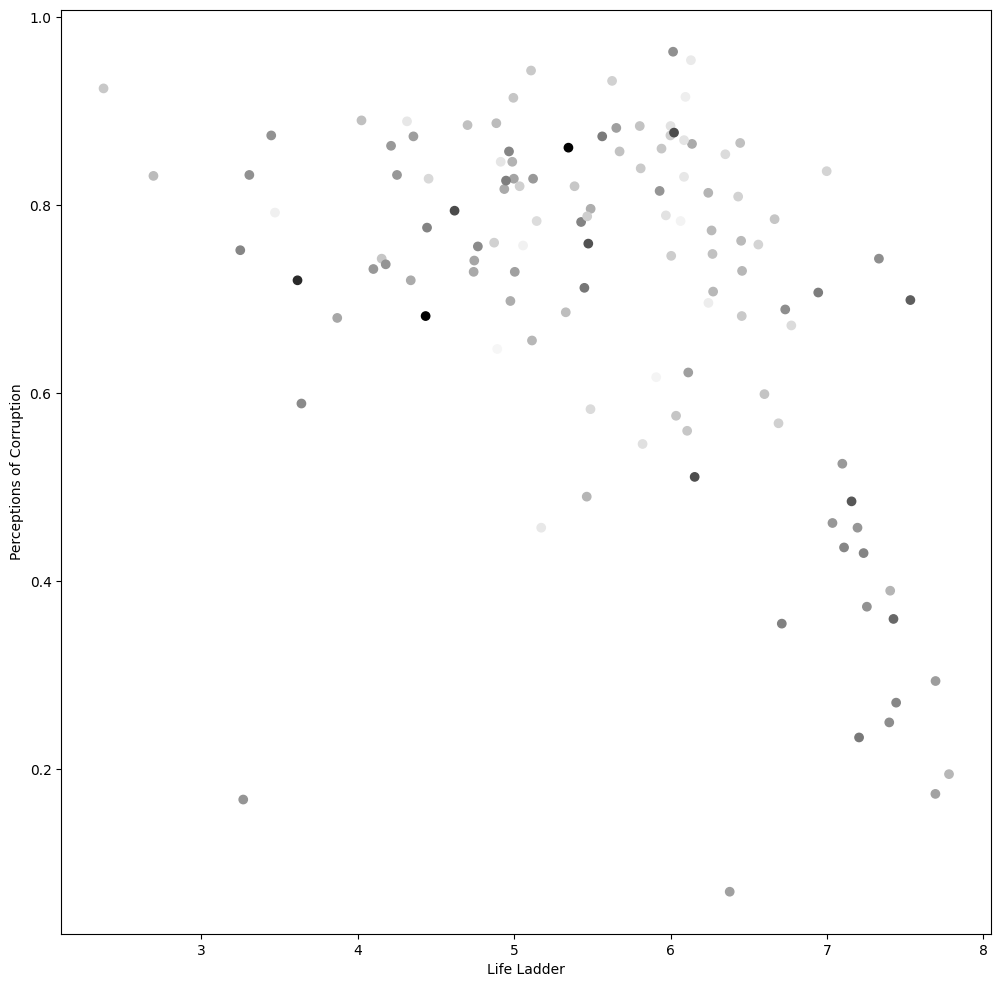

In [9]:
plt.figure(figsize=(12,12))
plt.scatter(report2019_df.Life_Ladder,
            report2019_df.Perceptions_of_corruption,
            c=report2019_df.Generosity,
            cmap='binary')
plt.xlabel('Life Ladder')
plt.ylabel('Perceptions of Corruption')
plt.show()

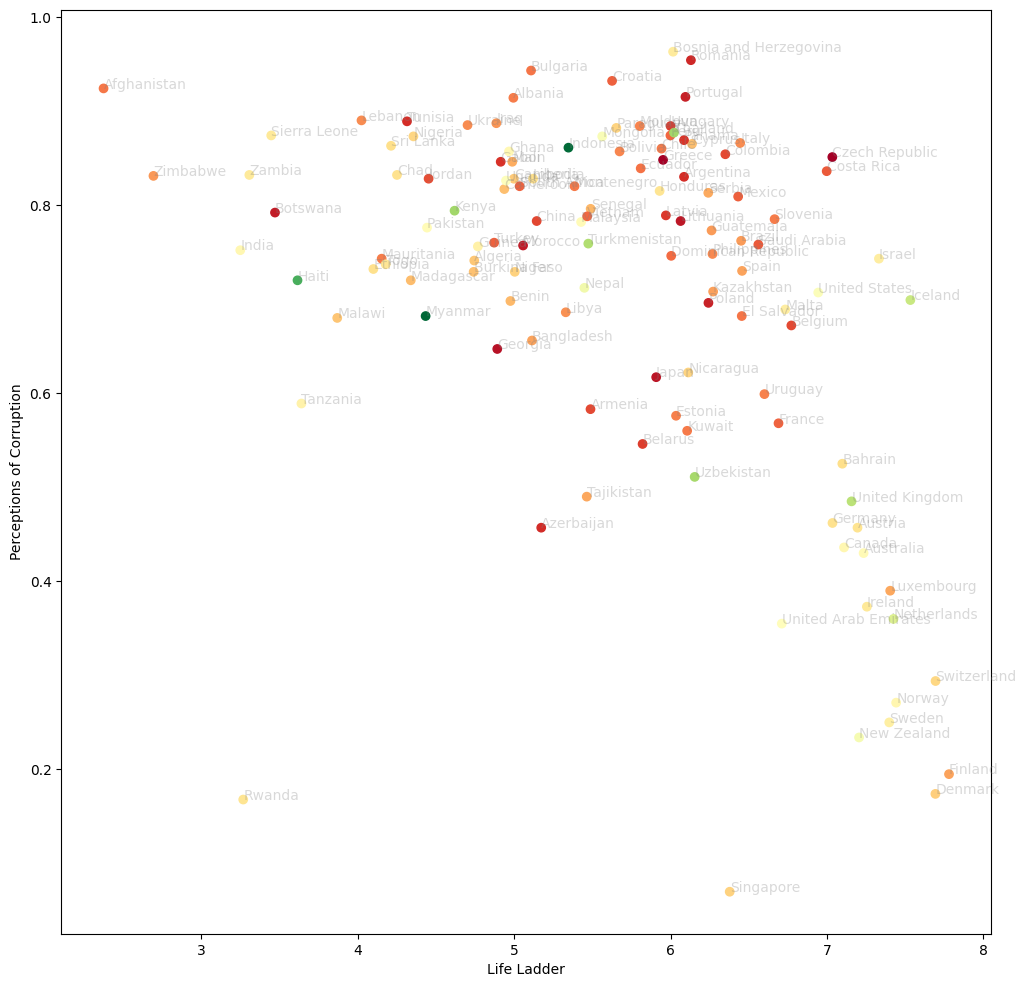

In [22]:
plt.figure(figsize=(12,12))
plt.scatter(report2019_df.Life_Ladder,
            report2019_df.Perceptions_of_corruption,
            c=report2019_df.Generosity,
            cmap='RdYlGn')
for _, row in report2019_df.iterrows():
    #attach name to data point
    plt.annotate(row.Name, 
                 (row.Life_Ladder, 
                  row.Perceptions_of_corruption),
                 c='grey',
                 alpha=0.3)
plt.xlabel('Life Ladder')
plt.ylabel('Perceptions of Corruption')
plt.show()

### K-Means algorithm

In [11]:
from sklearn.cluster import KMeans

In [12]:
dimensions = ['Life_Ladder','Perceptions_of_corruption']
Xs = report2019_df[dimensions]
kmeans = KMeans(n_clusters=6)
kmeans.fit(Xs)

KMeans(n_clusters=6)

In [14]:
# list out countries assocaited with each cluster
for i in range(6):
    BM = kmeans.labels_==i
    print('Clster {}:{}'.format(i, report2019_df[BM].Name.values))

Clster 0:['Albania' 'Algeria' 'Azerbaijan' 'Bangladesh' 'Benin' 'Bulgaria'
 'Burkina Faso' 'Cambodia' 'Cameroon' 'China' 'Gabon' 'Georgia' 'Ghana'
 'Guinea' 'Indonesia' 'Iraq' 'Jordan' 'Kenya' 'Liberia' 'Libya' 'Mali'
 'Morocco' 'Myanmar' 'Niger' 'Pakistan' 'South Africa' 'Turkey' 'Uganda'
 'Ukraine']
Clster 1:['Belgium' 'Brazil' 'Colombia' 'El Salvador' 'France' 'Guatemala' 'Italy'
 'Kazakhstan' 'Kuwait' 'Malta' 'Mexico' 'Nicaragua' 'Philippines' 'Poland'
 'Saudi Arabia' 'Serbia' 'Singapore' 'Slovenia' 'Spain'
 'United Arab Emirates' 'Uruguay' 'Uzbekistan']
Clster 2:['Afghanistan' 'Zimbabwe']
Clster 3:['Argentina' 'Armenia' 'Belarus' 'Bolivia' 'Bosnia and Herzegovina'
 'Chile' 'Croatia' 'Cyprus' 'Dominican Republic' 'Ecuador' 'Estonia'
 'Greece' 'Honduras' 'Hungary' 'Japan' 'Latvia' 'Lithuania' 'Malaysia'
 'Moldova' 'Mongolia' 'Montenegro' 'Nepal' 'Panama' 'Paraguay' 'Peru'
 'Portugal' 'Romania' 'Senegal' 'Tajikistan' 'Thailand' 'Turkmenistan'
 'Vietnam']
Clster 4:['Australia' 'Austri

In [23]:
# list out countries assocaited with each cluster
# this should look different from above even though it is the same code. Kmenas is randomized on the initial k values
from sklearn.cluster import KMeans
dimensions = ['Life_Ladder','Perceptions_of_corruption']
Xs = report2019_df[dimensions]
kmeans = KMeans(n_clusters=6)
kmeans.fit(Xs)

for i in range(6):
    BM = kmeans.labels_==i
    print('Cluster {}: {}'.format(i,report2019_df[BM].Name.values))

Cluster 0: ['Albania' 'Algeria' 'Armenia' 'Azerbaijan' 'Bangladesh' 'Benin'
 'Bulgaria' 'Burkina Faso' 'Cambodia' 'Cameroon' 'China' 'Gabon' 'Georgia'
 'Ghana' 'Guinea' 'Indonesia' 'Iraq' 'Liberia' 'Libya' 'Malaysia' 'Mali'
 'Montenegro' 'Morocco' 'Nepal' 'Niger' 'Senegal' 'South Africa'
 'Tajikistan' 'Turkey' 'Turkmenistan' 'Uganda' 'Ukraine' 'Vietnam']
Cluster 1: ['Australia' 'Austria' 'Bahrain' 'Canada' 'Denmark' 'Finland' 'Germany'
 'Iceland' 'Ireland' 'Israel' 'Luxembourg' 'Netherlands' 'New Zealand'
 'Norway' 'Sweden' 'Switzerland' 'United Kingdom']
Cluster 2: ['Afghanistan' 'Botswana' 'Haiti' 'India' 'Rwanda' 'Sierra Leone'
 'Tanzania' 'Zambia' 'Zimbabwe']
Cluster 3: ['Belgium' 'Brazil' 'Colombia' 'Costa Rica' 'Czech Republic' 'El Salvador'
 'France' 'Italy' 'Malta' 'Mexico' 'Saudi Arabia' 'Singapore' 'Slovenia'
 'Spain' 'United Arab Emirates' 'United States' 'Uruguay']
Cluster 4: ['Chad' 'Ethiopia' 'Jordan' 'Kenya' 'Lebanon' 'Madagascar' 'Malawi'
 'Mauritania' 'Myanmar' 'Nigeri

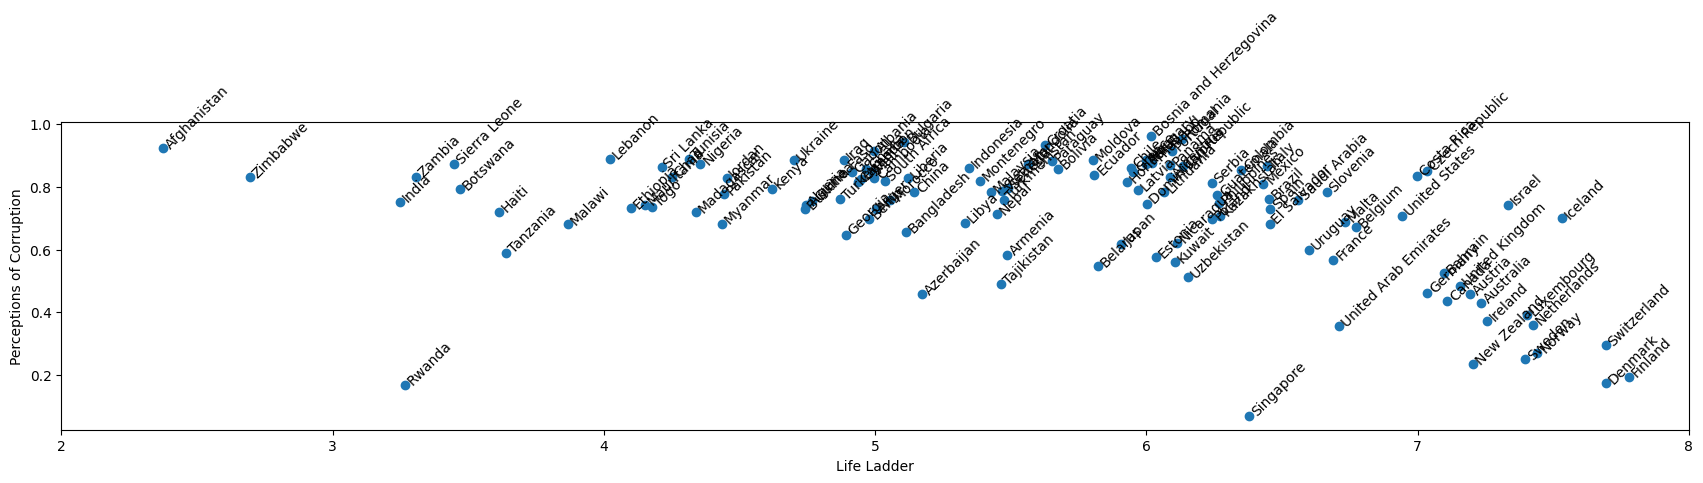

In [19]:
# plot out the life ladder and perceptions of corruption data points
# include the name of each country using annotate
plt.figure(figsize=(21,4))
plt.scatter(report2019_df.Life_Ladder,
            report2019_df.Perceptions_of_corruption)
for _, row in report2019_df.iterrows():
    plt.annotate(row.Name, 
                 (row.Life_Ladder,
                  row.Perceptions_of_corruption),
                 rotation=45)
plt.xlim([2,8])
plt.xlabel('Life Ladder')
plt.ylabel('Perceptions of Corruption')
plt.show()

In [27]:
# Normalize the life ladder and perceptions of corruption attributes and then perform kmeans clustering
dimensions = ['Life_Ladder','Perceptions_of_corruption']
Xs = report2019_df[dimensions]
Xs = (Xs-Xs.min())/(Xs.max()-Xs.min())
kmeans.fit(Xs)

for i in range(6):
    BM = kmeans.labels_==i
    print('Cluster {}:{}'.format(i, report2019_df[BM].Name.values))

Cluster 0:['Argentina' 'Bolivia' 'Bosnia and Herzegovina' 'Brazil' 'Chile'
 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Dominican Republic' 'Ecuador' 'Greece' 'Guatemala' 'Honduras' 'Hungary'
 'Italy' 'Latvia' 'Lithuania' 'Mexico' 'Moldova' 'Mongolia' 'Panama'
 'Paraguay' 'Peru' 'Philippines' 'Portugal' 'Romania' 'Saudi Arabia'
 'Serbia' 'Slovenia' 'Thailand']
Cluster 1:['Afghanistan' 'Botswana' 'Chad' 'Ethiopia' 'Haiti' 'India' 'Lebanon'
 'Malawi' 'Mauritania' 'Sierra Leone' 'Sri Lanka' 'Tanzania' 'Togo'
 'Tunisia' 'Zambia' 'Zimbabwe']
Cluster 2:['Armenia' 'Azerbaijan' 'Bahrain' 'Belarus' 'Belgium' 'El Salvador'
 'Estonia' 'France' 'Iceland' 'Israel' 'Japan' 'Kazakhstan' 'Kuwait'
 'Malta' 'Nicaragua' 'Poland' 'Spain' 'Tajikistan' 'United States'
 'Uruguay' 'Uzbekistan']
Cluster 3:['Albania' 'Algeria' 'Bangladesh' 'Benin' 'Bulgaria' 'Burkina Faso'
 'Cambodia' 'Cameroon' 'China' 'Gabon' 'Georgia' 'Ghana' 'Guinea'
 'Indonesia' 'Iraq' 'Jordan' 'Kenya' 'Liberia' 'Libya' '

### Use kmeans on multiple attributes

In [34]:
dimensions = ['Life_Ladder','Log_GDP_per_capita','Social_support', \
              'Healthy_life_expectancy_at_birth','Freedom_to_make_life_choices', \
              'Generosity','Perceptions_of_corruption','Positive_affect','Negative_affect']
Xs = report2019_df[dimensions]
Xs = (Xs-Xs.min())/(Xs.max()-Xs.min())
kmeans = KMeans(n_clusters=3)
kmeans.fit(Xs)
for i in range(3):
    BM = kmeans.labels_==i
    print('Cluster {}:{}'.format(i, report2019_df[BM].Name.values))

Cluster 0:['Albania' 'Algeria' 'Argentina' 'Armenia' 'Azerbaijan' 'Belarus'
 'Belgium' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Chile' 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus'
 'Czech Republic' 'Dominican Republic' 'Ecuador' 'El Salvador' 'Georgia'
 'Greece' 'Guatemala' 'Honduras' 'Hungary' 'Indonesia' 'Italy' 'Japan'
 'Kazakhstan' 'Kuwait' 'Latvia' 'Libya' 'Lithuania' 'Malaysia' 'Mexico'
 'Moldova' 'Mongolia' 'Montenegro' 'Nicaragua' 'Panama' 'Paraguay' 'Peru'
 'Philippines' 'Poland' 'Portugal' 'Romania' 'Saudi Arabia' 'Serbia'
 'Slovenia' 'South Africa' 'Spain' 'Sri Lanka' 'Tajikistan' 'Thailand'
 'Turkey' 'Turkmenistan' 'Ukraine' 'Vietnam']
Cluster 1:['Afghanistan' 'Bangladesh' 'Benin' 'Burkina Faso' 'Cambodia' 'Cameroon'
 'Chad' 'Ethiopia' 'Gabon' 'Ghana' 'Guinea' 'Haiti' 'India' 'Iraq'
 'Jordan' 'Kenya' 'Lebanon' 'Liberia' 'Madagascar' 'Malawi' 'Mali'
 'Mauritania' 'Morocco' 'Myanmar' 'Nepal' 'Niger' 'Nigeria' 'Pakistan'
 'Rwanda' 'Senegal' 'Si

### Centroid Analysis

In [35]:
import seaborn as sns

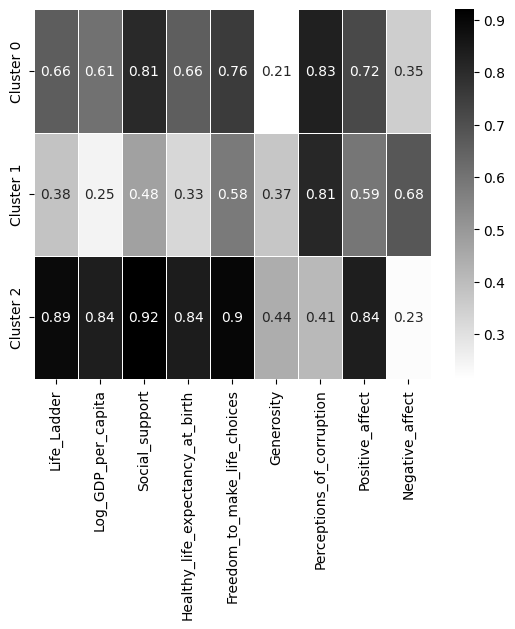

In [36]:
clusters = ['Cluster {}'.format(i) for i in range(3)]
Centroids = pd.DataFrame(0.0, index=clusters, columns=Xs.columns)
for i,clst in enumerate(clusters):
    BM = kmeans.labels_ == i
    Centroids.loc[clst] = Xs[BM].median(axis=0)
sns.heatmap(Centroids, linewidth=0.5, annot=True,cmap='binary')
plt.show()